# Data-Driven Insights for Seasonal Retail (EDA)

## Project Overview

This project applies **Exploratory Data Analysis (EDA)** to **RetailMart**, a mid-sized US retail chain operating **150 stores** across four regions (North, South, East, West) and trading in three product categories: **Electronics, Apparel, and Home Goods**. Using **Pandas, Matplotlib, and Seaborn**, daily transaction data spanning **1 January 2022 to 30 September 2024** is explored to understand how *seasonality*, *advertising spend*, and *discounting* relate to **sales, customer activity, and profit**, and to turn those patterns into practical business decisions.

## Problem Statement

RetailMart's leadership lacks a clear, data-driven view of how seasonal patterns, advertising spend, and discount strategies translate into measurable outcomes such as profit and customer satisfaction. The analysis sets out to answer three core business questions:

- Are advertising budgets being allocated effectively to maximise sales?
- How do seasonality and discounts affect customer purchasing behaviour and profitability?
- Which product categories and regions should be prioritised during specific months or seasons?

## Objectives

1. **Visualise key business metrics** — analyse sales, profit, advertising, and customer-count trends over time.
2. **Understand seasonal trends** — quantify how sales and customer activity vary across months and seasons.
3. **Assess advertising effectiveness** — measure how advertising spend relates to sales and recommend better-timed budget allocation.
4. **Evaluate discount strategy** — understand how discounts influence customer counts, sales, and profit margins.
5. **Identify high-performing categories and regions** — determine where sales and profit concentrate.
6. **Deliver data-driven recommendations** — translate the findings into actionable business decisions.

In [2]:
#Import relevant libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the data

df = pd.read_csv(r"D:\Data Scientist\Sections\Section 13 - Exploratory Data Analytics EDA\retailmart_data.csv")

In [4]:
# Understand the data

df.head()

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.90
1,2022-01-02,Electronics,West,Cloudy,1893.89,24.74,January,2022,Winter,3859.05,147,924.16
2,2022-01-02,Apparel,East,Sunny,727.38,8.46,January,2022,Winter,2450.71,79,512.75
3,2022-01-02,Apparel,South,Rainy,1757.23,15.37,January,2022,Winter,3056.75,97,624.60
4,2022-01-05,Home Goods,North,Cloudy,1507.46,16.22,January,2022,Winter,2840.15,116,617.43


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1000 non-null   object 
 1   Category        1000 non-null   object 
 2   Region          1000 non-null   object 
 3   Weather         1000 non-null   object 
 4   Advertising     1000 non-null   float64
 5   Discount        1000 non-null   float64
 6   Month           1000 non-null   object 
 7   Year            1000 non-null   int64  
 8   Season          1000 non-null   object 
 9   Sales           1000 non-null   float64
 10  Customer_Count  1000 non-null   int64  
 11  Profit          1000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 93.9+ KB


# Time series analysis

In [6]:
# Convert date column to pandas datetime format (it's object which is categorical data)

df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1000 non-null   datetime64[ns]
 1   Category        1000 non-null   object        
 2   Region          1000 non-null   object        
 3   Weather         1000 non-null   object        
 4   Advertising     1000 non-null   float64       
 5   Discount        1000 non-null   float64       
 6   Month           1000 non-null   object        
 7   Year            1000 non-null   int64         
 8   Season          1000 non-null   object        
 9   Sales           1000 non-null   float64       
 10  Customer_Count  1000 non-null   int64         
 11  Profit          1000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 93.9+ KB


In [8]:
# What range of date do we have in this data

df["Date"].min()

Timestamp('2022-01-01 00:00:00')

In [9]:
df["Date"].max()

Timestamp('2024-09-30 00:00:00')

# 1. Sales trend over time for different categories

In [10]:
df["Category"].unique()

array(['Home Goods', 'Electronics', 'Apparel'], dtype=object)

In [11]:
# Filter all the individual categories

home_goods = df[df["Category"] == "Home Goods"]
electronics = df[df["Category"] == "Electronics"]
apparel = df[df["Category"] == "Apparel"]
home_goods

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.90
4,2022-01-05,Home Goods,North,Cloudy,1507.46,16.22,January,2022,Winter,2840.15,116,617.43
5,2022-01-05,Home Goods,North,Rainy,1576.36,10.18,January,2022,Winter,2384.53,81,594.50
9,2022-01-10,Home Goods,South,Snowy,1681.06,12.21,January,2022,Winter,2723.22,98,614.62
10,2022-01-12,Home Goods,East,Cloudy,1145.15,10.42,January,2022,Winter,2341.12,83,606.44
...,...,...,...,...,...,...,...,...,...,...,...,...
982,2024-09-12,Home Goods,West,Cloudy,1092.10,28.21,September,2024,Fall,2371.27,161,629.08
987,2024-09-18,Home Goods,West,Rainy,1476.44,27.62,September,2024,Fall,2760.43,161,594.41
991,2024-09-22,Home Goods,North,Cloudy,597.03,28.33,September,2024,Fall,2191.84,163,546.20
997,2024-09-29,Home Goods,North,Snowy,936.72,29.62,September,2024,Fall,2516.03,176,560.81


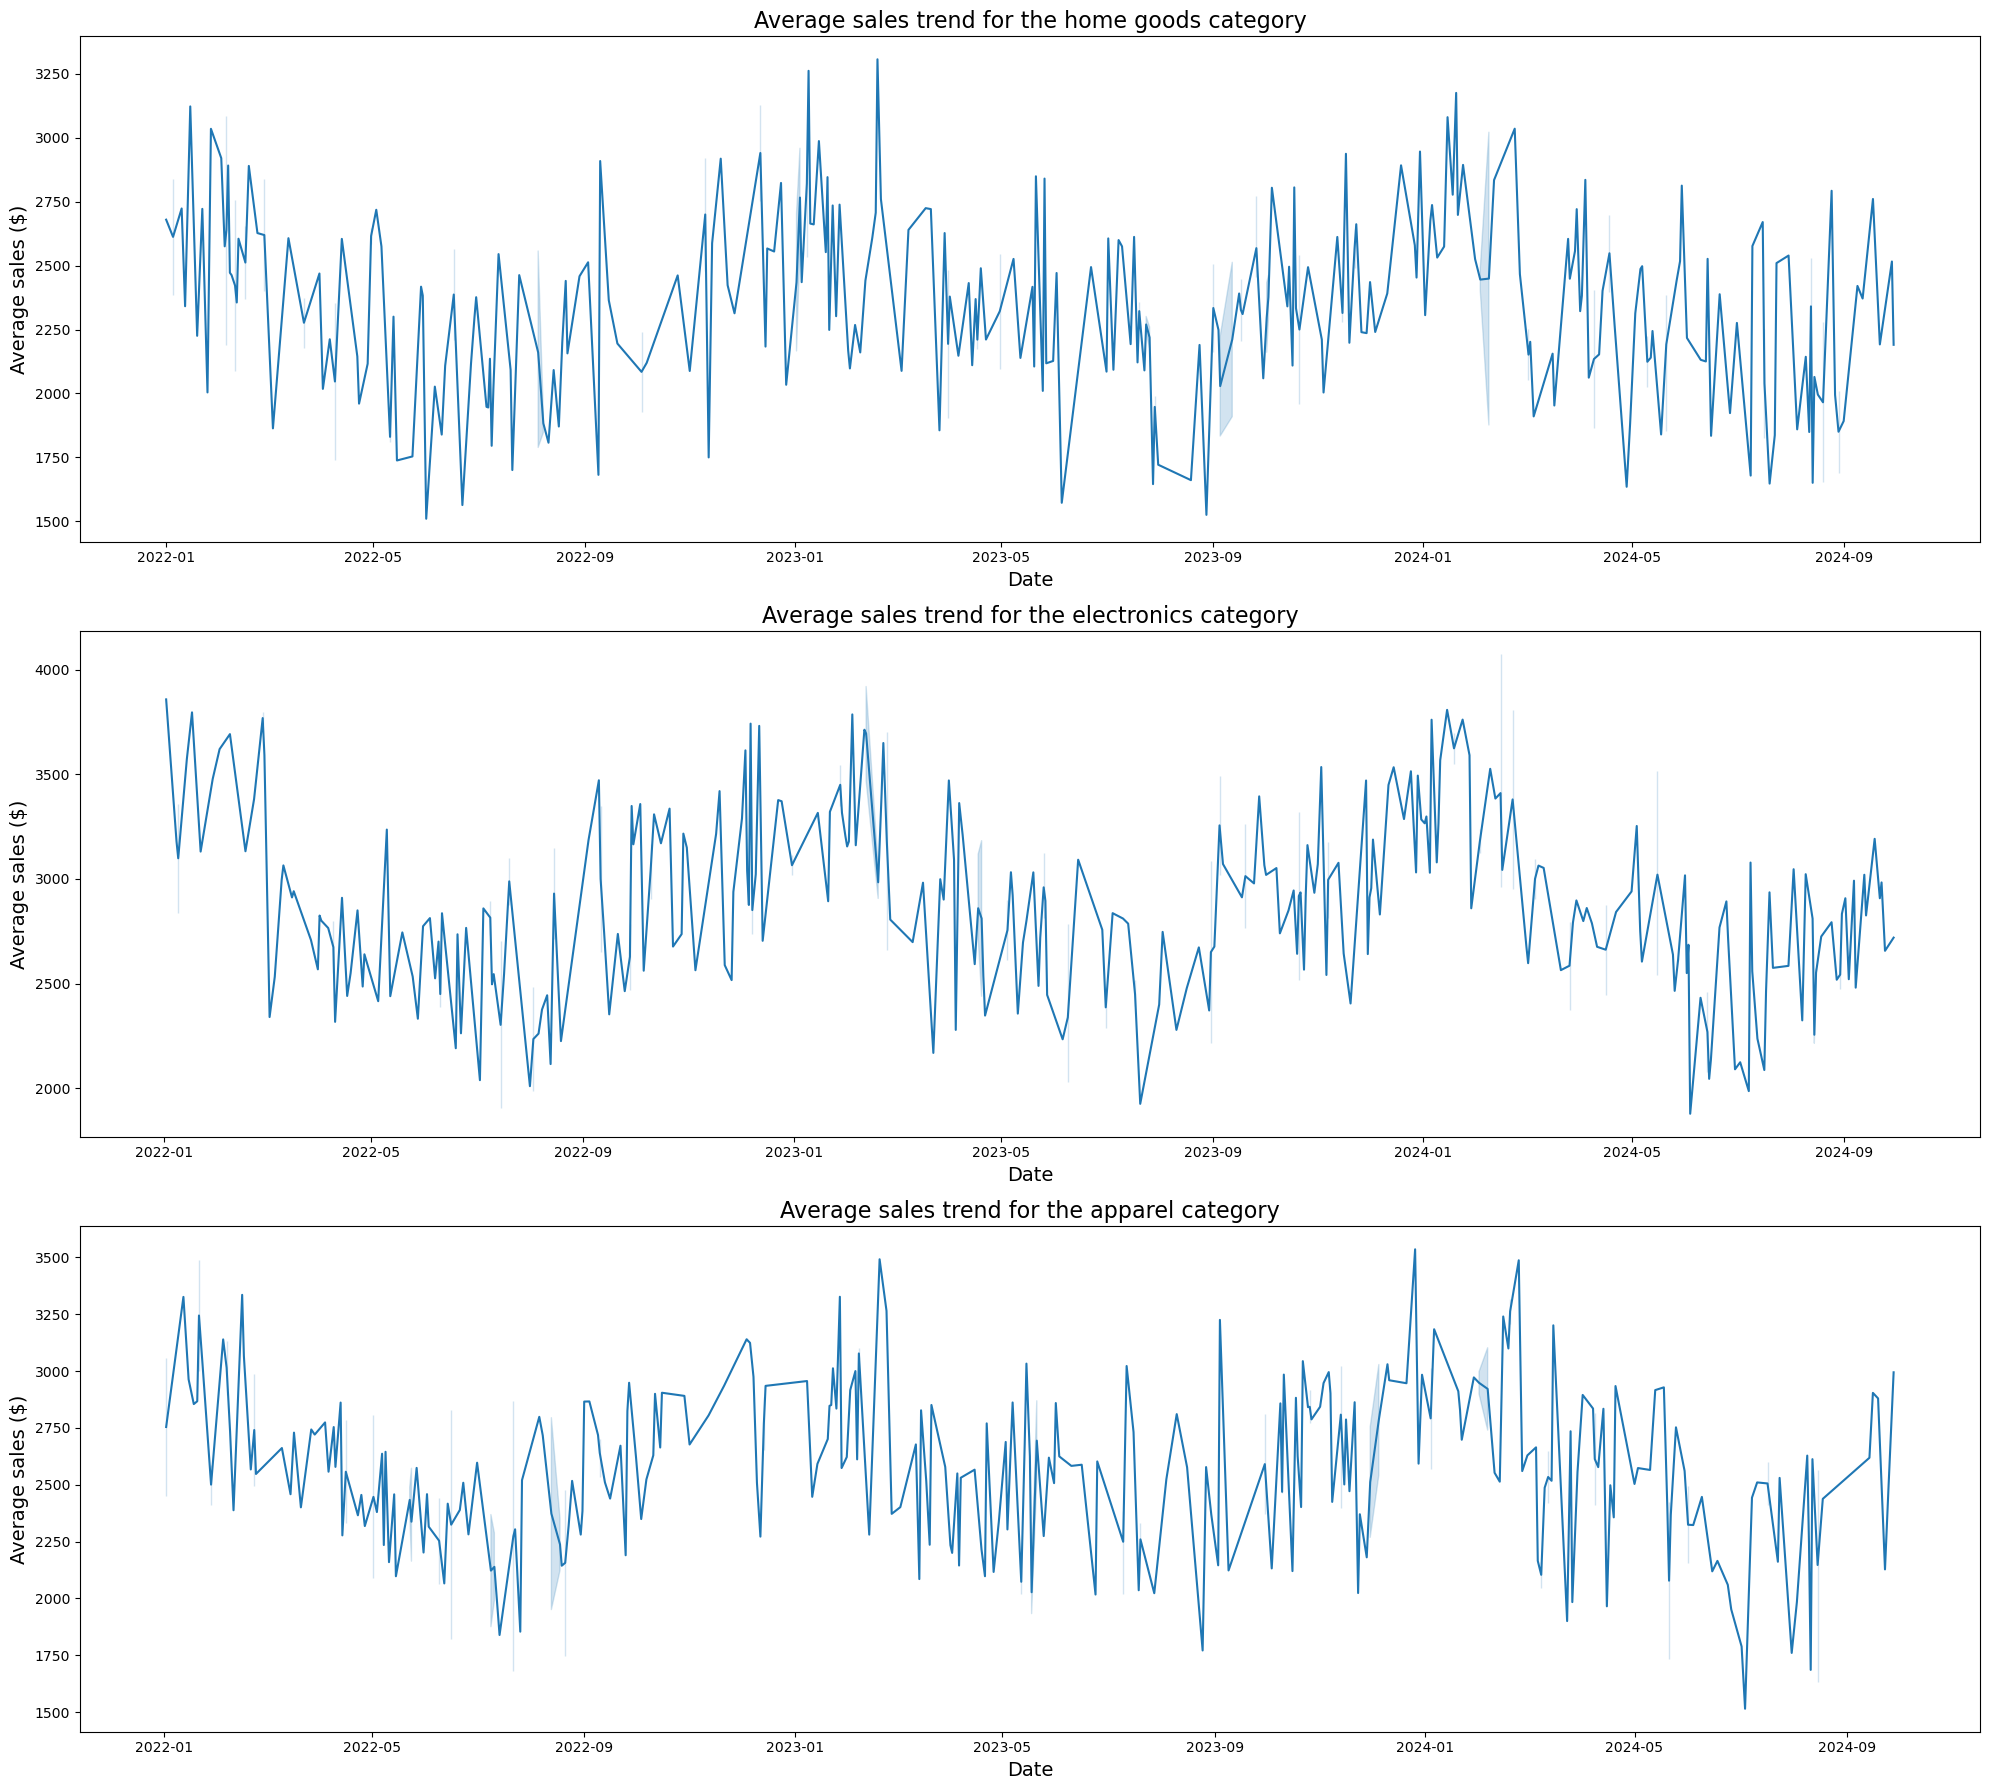

In [12]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(20, 18))

sns.lineplot(x="Date", y="Sales", data=home_goods, ax=ax[0])
ax[0].set_title("Average sales trend for the home goods category", fontsize=16)
ax[0].set_xlabel("Date", fontsize=14)
ax[0].set_ylabel("Average sales ($)", fontsize=14)

sns.lineplot(x="Date", y="Sales", data=electronics, ax=ax[1])
ax[1].set_title("Average sales trend for the electronics category", fontsize=16)
ax[1].set_xlabel("Date", fontsize=14)
ax[1].set_ylabel("Average sales ($)", fontsize=14)

sns.lineplot(x="Date", y="Sales", data=apparel, ax=ax[2])
ax[2].set_title("Average sales trend for the apparel category", fontsize=16)
ax[2].set_xlabel("Date", fontsize=14)
ax[2].set_ylabel("Average sales ($)", fontsize=14)

plt.tight_layout()
plt.show()


**Insight**: Seasonal spikes are visible during the holiday months (January-December) and slight dips during the summer months

# 2. Visualise this seasonality across monthly sales 

In [13]:
df.head(1)

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.9


In [14]:
# Let's have year and month

df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

In [42]:
df.head(10)

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit,Year_Month
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.90,2022-01
1,2022-01-02,Electronics,West,Cloudy,1893.89,24.74,January,2022,Winter,3859.05,147,924.16,2022-01
2,2022-01-02,Apparel,East,Sunny,727.38,8.46,January,2022,Winter,2450.71,79,512.75,2022-01
3,2022-01-02,Apparel,South,Rainy,1757.23,15.37,January,2022,Winter,3056.75,97,624.60,2022-01
4,2022-01-05,Home Goods,North,Cloudy,1507.46,16.22,January,2022,Winter,2840.15,116,617.43,2022-01
5,2022-01-05,Home Goods,North,Rainy,1576.36,10.18,January,2022,Winter,2384.53,81,594.50,2022-01
6,2022-01-08,Electronics,West,Snowy,1506.01,5.62,January,2022,Winter,3180.64,52,726.82,2022-01
7,2022-01-09,Electronics,North,Sunny,1599.58,18.25,January,2022,Winter,3360.72,120,725.93,2022-01
8,2022-01-09,Electronics,South,Rainy,963.25,6.26,January,2022,Winter,2837.33,60,681.25,2022-01
9,2022-01-10,Home Goods,South,Snowy,1681.06,12.21,January,2022,Winter,2723.22,98,614.62,2022-01


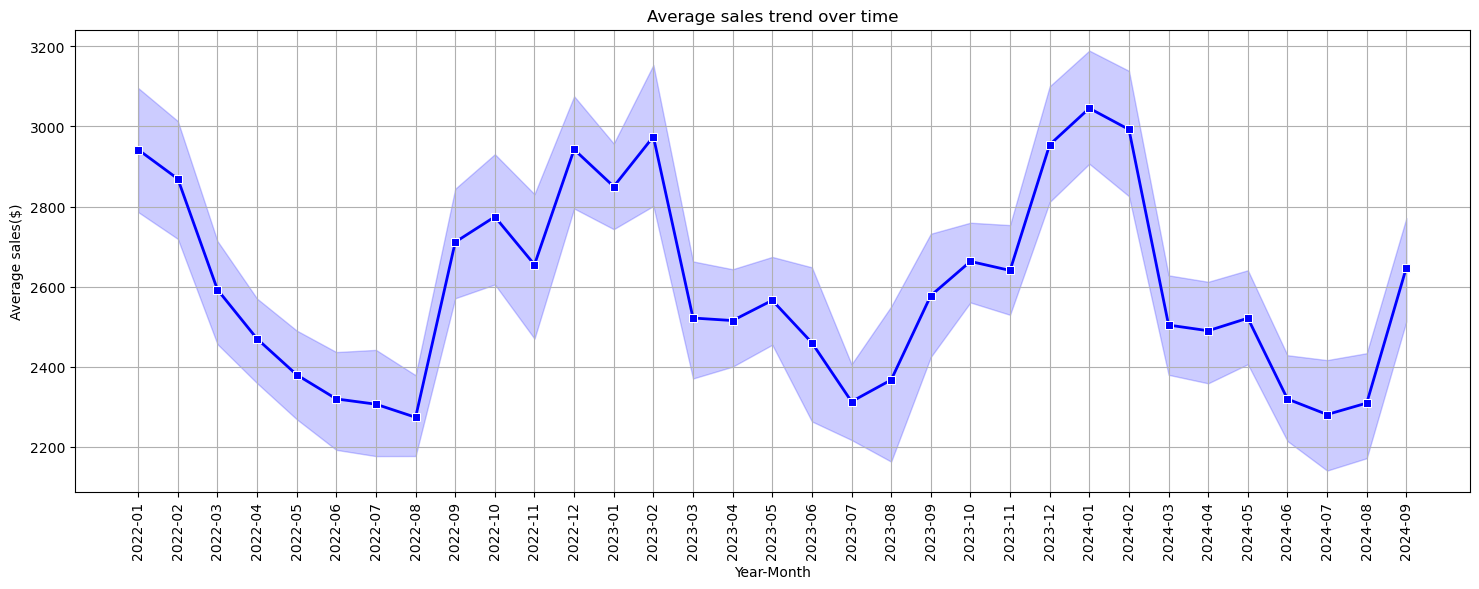

In [16]:
plt.figure(figsize=(18,6))

sns.lineplot(x="Year_Month", y="Sales", data=df, color="blue", marker="s", linewidth=2)
plt.title("Average sales trend over time")
plt.xlabel("Year-Month")
plt.ylabel("Average sales($)")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

**Insight**: Seasonal appears in the data, sales are up around the holiday seasons (from September to December) and dips during summer

# 3. Lets confirm this trend by plotting the average monthly sales across different seasons

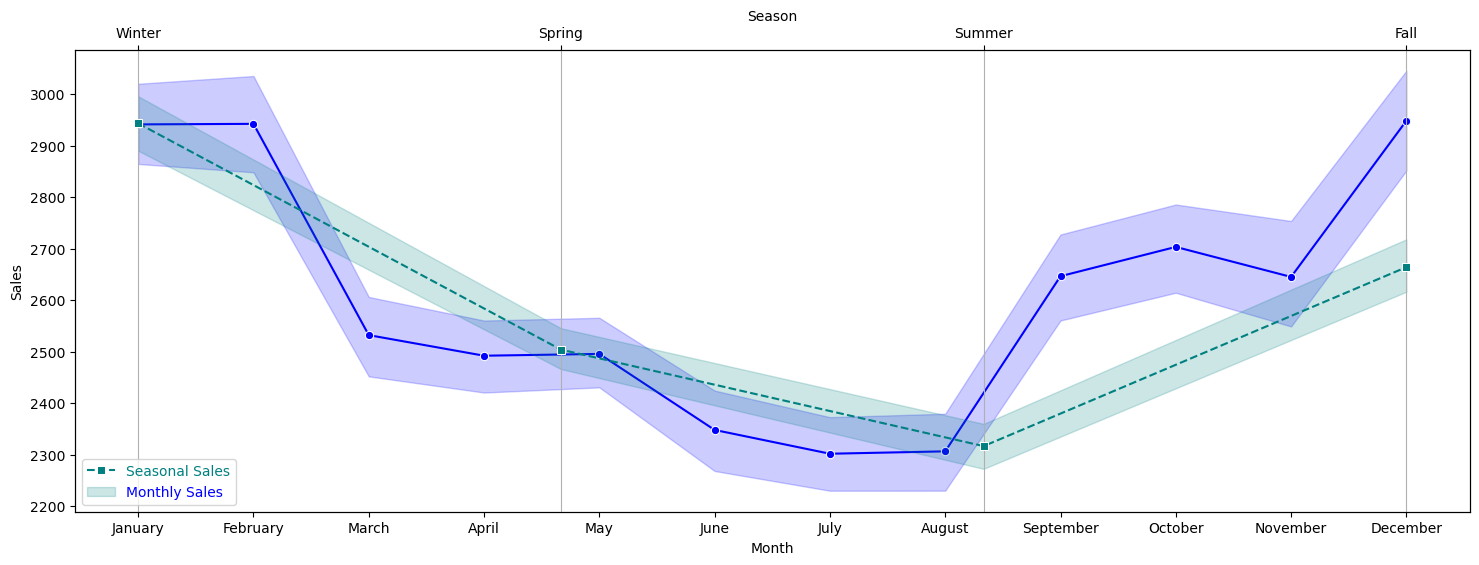

In [17]:
fig, ax = plt.subplots(figsize=(18,6))

sns.lineplot(x="Month", y="Sales", data=df, color="blue", marker="o")
ax2 = ax.twiny()
sns.lineplot(x="Season", y="Sales", data=df, color="teal", marker="s", linestyle="--")

plt.legend(labels=["Seasonal Sales", "Monthly Sales"], loc="lower left", labelcolor=["teal", "blue"])

plt.grid(True)
plt.show()

**Insight**: The seasonality peak (in winter and fall) and dip (in spring and summer) in sales is confirmed as suspected

# 4. Customer Activity Analysis

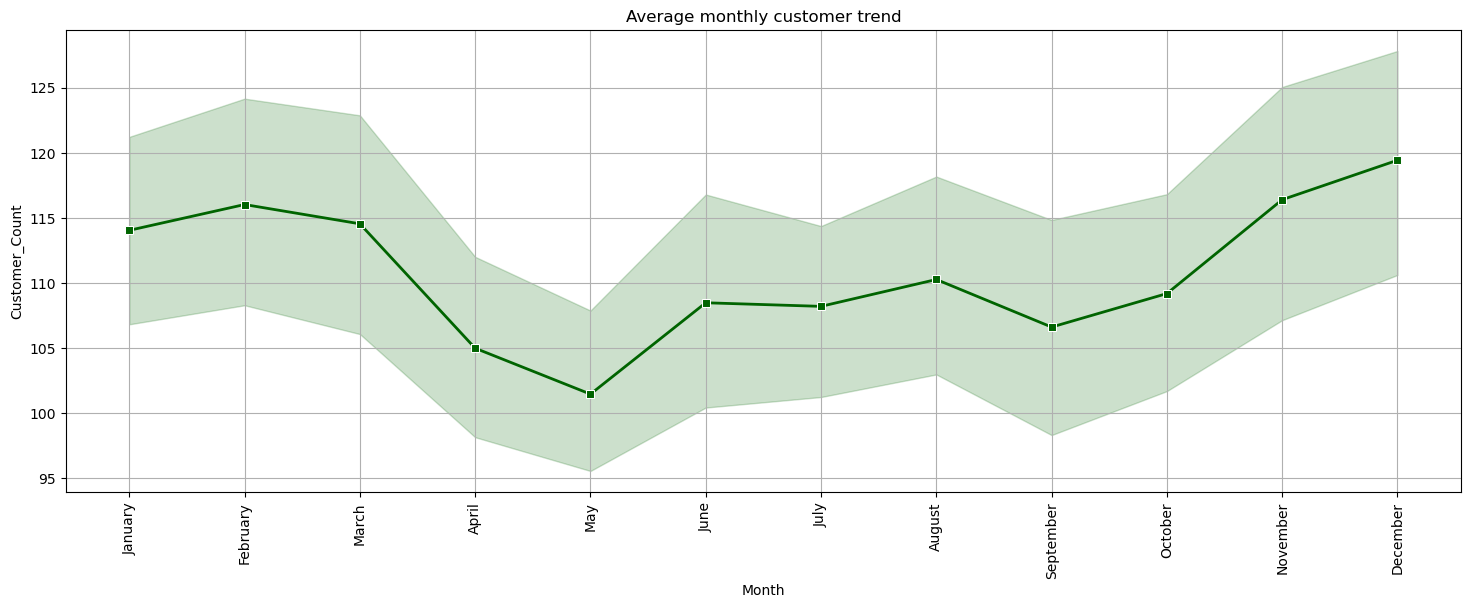

In [18]:
plt.figure(figsize=(18,6))

sns.lineplot(x="Month", y="Customer_Count", data=df, color="darkgreen", marker="s", linewidth=2)
plt.title("Average monthly customer trend")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

**Insight**: Customer activity spikes during holiday seasons, aligning with sales trends

# 5. Lets see the same analysis over the entire timeline

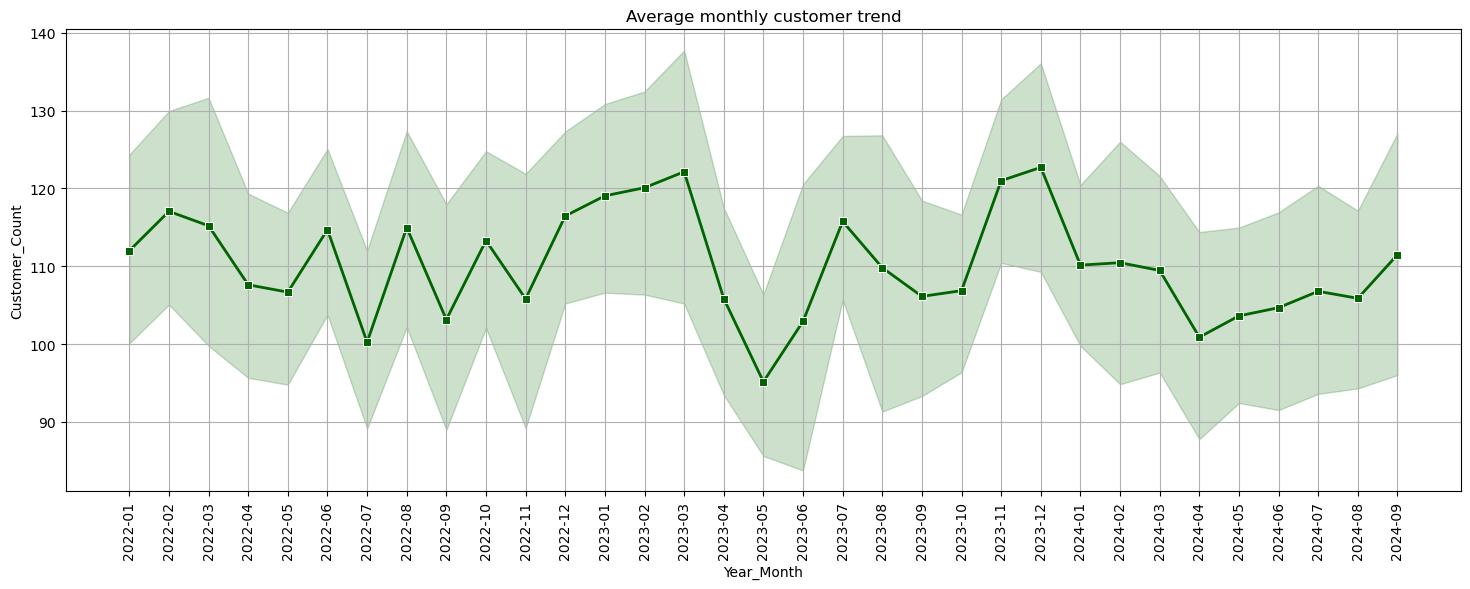

In [19]:
plt.figure(figsize=(18,6))

sns.lineplot(x="Year_Month", y="Customer_Count", data=df, color="darkgreen", marker="s", linewidth=2)
plt.title("Average monthly customer trend")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

**Insight**: 2023's holiday season had the most customer growth, meanwhile the spring of the same year also had the highest dip in customer count

# 6. Advertising Analysis

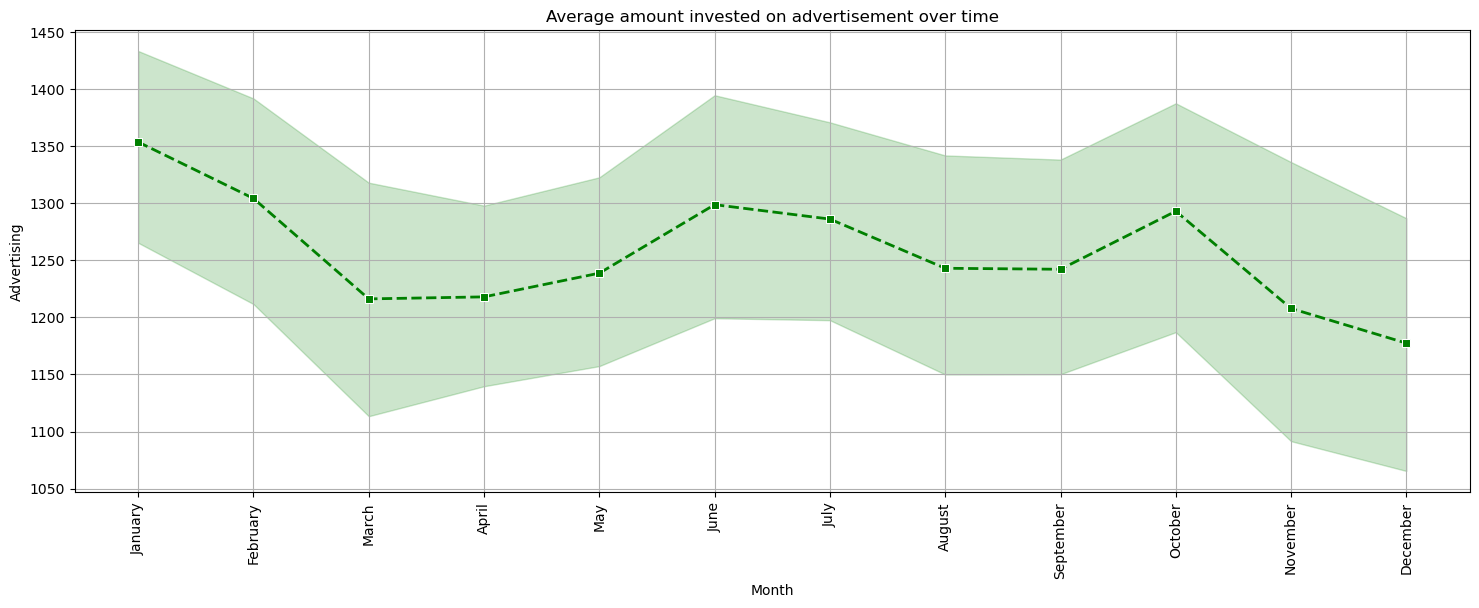

In [20]:
plt.figure(figsize=(18,6))

sns.lineplot(x="Month", y="Advertising", data=df, color="green", marker="s", linewidth=2, linestyle="--")
plt.title("Average amount invested on advertisement over time")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

**Insight**: Reduction in advertisement budget during holiday seasons when sales is expected to peak normally

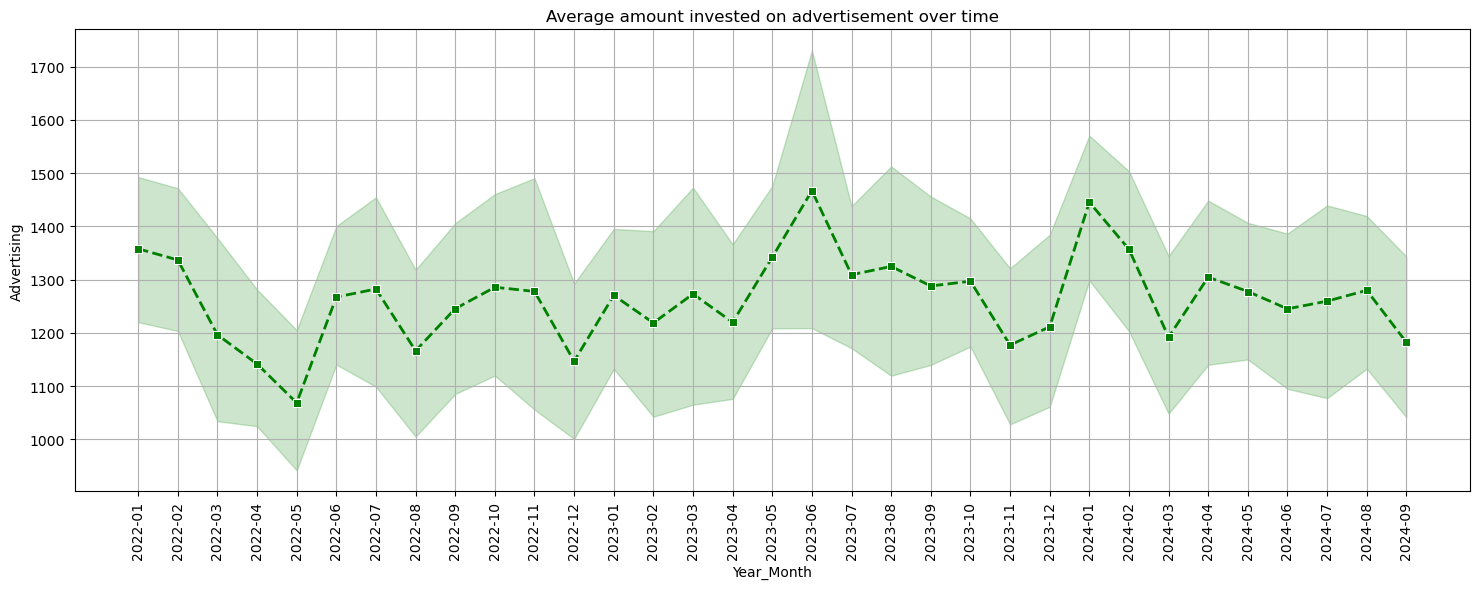

In [21]:
plt.figure(figsize=(18,6))

sns.lineplot(x="Year_Month", y="Advertising", data=df, color="green", marker="s", linewidth=2, linestyle="--")
plt.title("Average amount invested on advertisement over time")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

**Insight**: The holiday season and spring of 2023 again had the largest budget for advertisement. As in previous chart, budget allocation for advertisement is expected to reduce during holiday seasons. However, the inverse was the case in 2023, probably due to the significant drop in customer activities earlier that same year.

# 7. Average advertising and sales trend over time

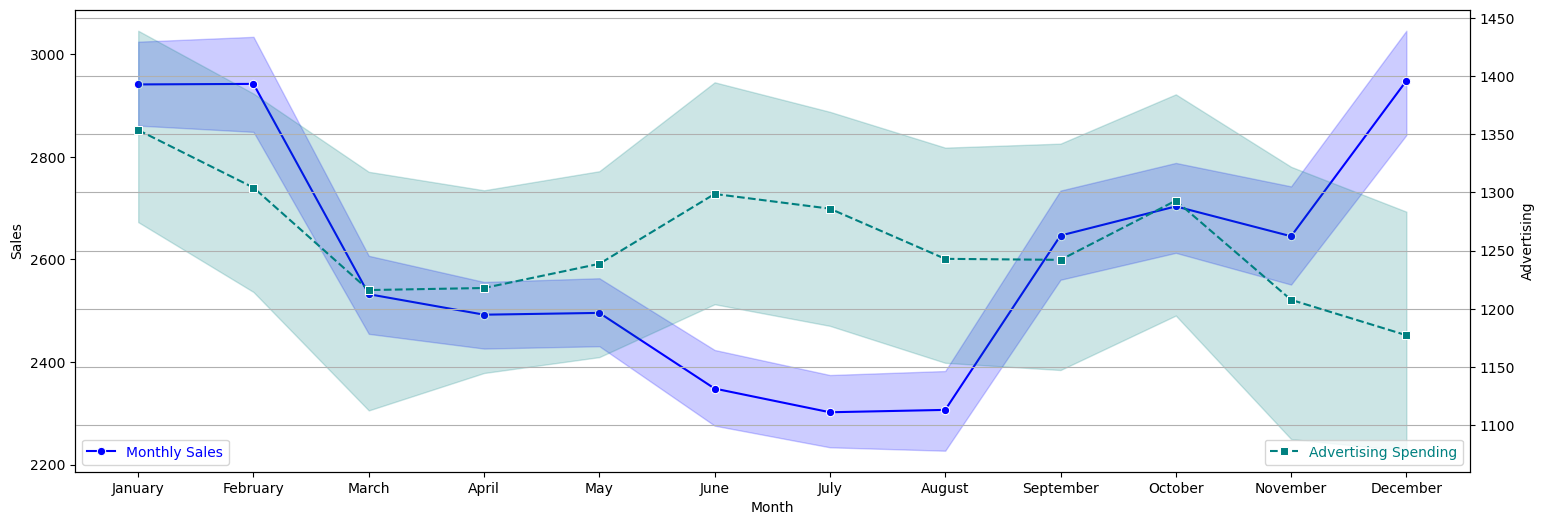

In [22]:
fig, ax = plt.subplots(figsize=(18,6))

sns.lineplot(x="Month", y="Sales", data=df, color="blue", marker="o", ax=ax)
ax.legend(labels=["Monthly Sales"], loc="lower left", labelcolor="blue")

ax2 = ax.twinx()
sns.lineplot(x="Month", y="Advertising", data=df, color="teal", marker="s", linestyle="--", ax=ax2)
ax2.legend(labels=["Advertising Spending"], loc="lower right", labelcolor="teal") # can change advertising spending into Season Sales

plt.grid(True)
plt.show()

**Insight**: Sales activity spikes during holiday seasons, opposing advertisement trends.

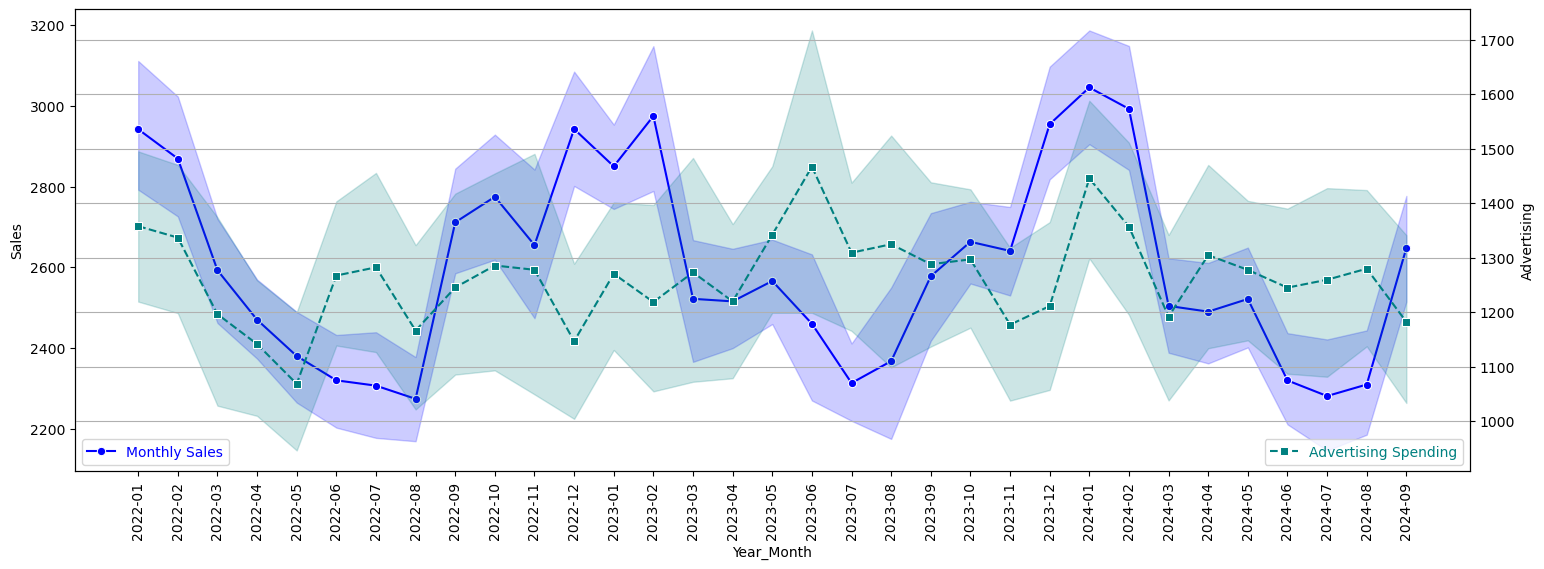

In [23]:
fig, ax = plt.subplots(figsize=(18,6))

sns.lineplot(x="Year_Month", y="Sales", data=df, color="blue", marker="o", ax=ax)
ax.legend(labels=["Monthly Sales"], loc="lower left", labelcolor="blue")
plt.xticks(rotation=90)

ax2 = ax.twinx()
sns.lineplot(x="Year_Month", y="Advertising", data=df, color="teal", marker="s", linestyle="--", ax=ax2)
ax2.legend(labels=["Advertising Spending"], loc="lower right", labelcolor="teal") # can change advertising spending into Season Sales

plt.grid(True)
plt.show()

**Insight**: A confirmation on the effect of advertisement budget during 2023 spring downward fall of customer activities and sales. The increase in budget allocation that year not only revive the sales but also pushed the sales to reach an all-time high.

# 8. Discount analysis over time

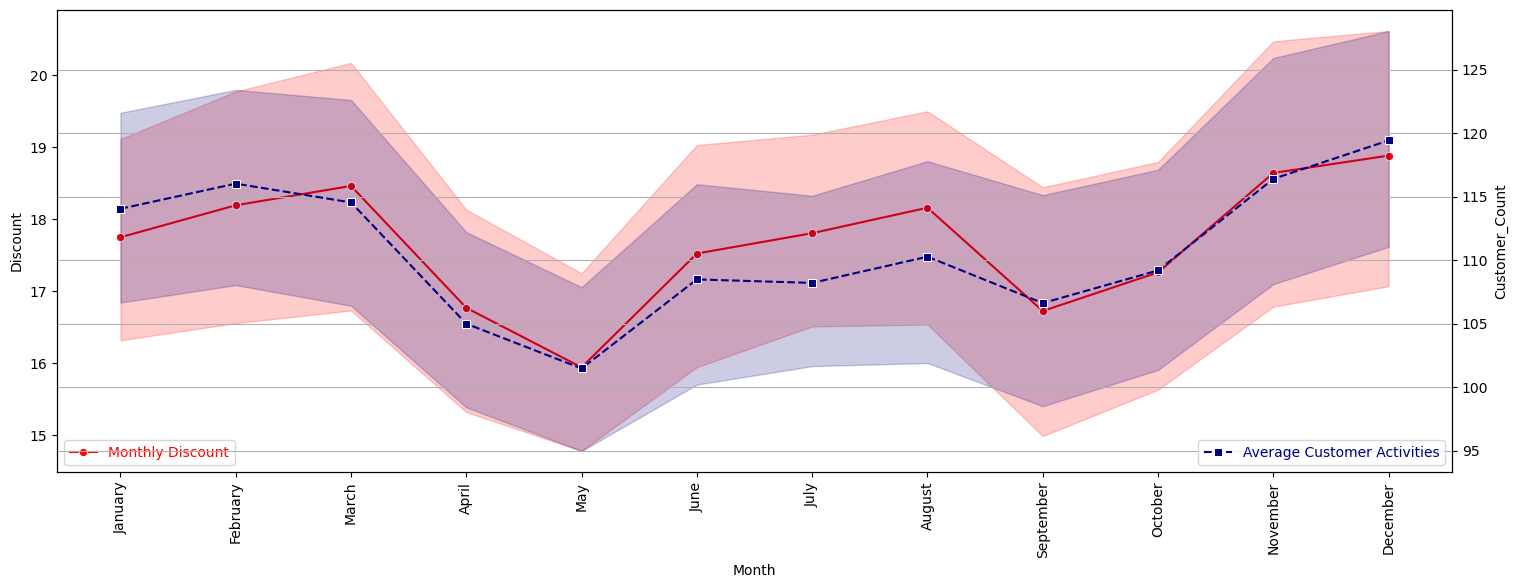

In [24]:
# Does discount account more customers

fig, ax = plt.subplots(figsize=(18,6))

sns.lineplot(x="Month", y="Discount", data=df, color="red", marker="o", ax=ax)
ax.legend(labels=["Monthly Discount"], loc="lower left", labelcolor="red")
plt.xticks(rotation=90)

ax2 = ax.twinx()
sns.lineplot(x="Month", y="Customer_Count", data=df, color="navy", marker="s", linestyle="--", ax=ax2)
ax2.legend(labels=["Average Customer Activities"], loc="lower right", labelcolor="navy") 

plt.grid(True)
plt.show()

**Insight**: Indeed higher discounts attract more customers

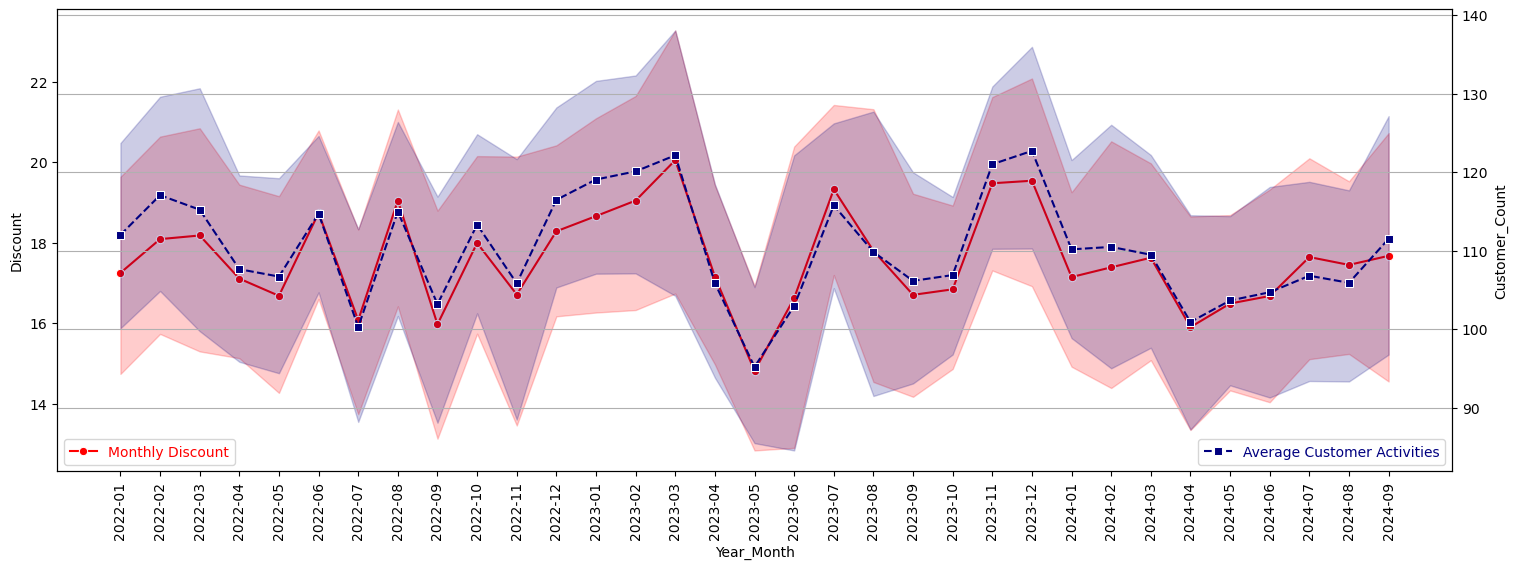

In [25]:
fig, ax = plt.subplots(figsize=(18,6))

sns.lineplot(x="Year_Month", y="Discount", data=df, color="red", marker="o", ax=ax)
ax.legend(labels=["Monthly Discount"], loc="lower left", labelcolor="red")
plt.xticks(rotation=90)

ax2 = ax.twinx()
sns.lineplot(x="Year_Month", y="Customer_Count", data=df, color="navy", marker="s", linestyle="--", ax=ax2)
ax2.legend(labels=["Average Customer Activities"], loc="lower right", labelcolor="navy") 

plt.grid(True)
plt.show()

**Insight**: The same trends continues throughout the years. i.e. higher discount more customers

# Categorical analysis

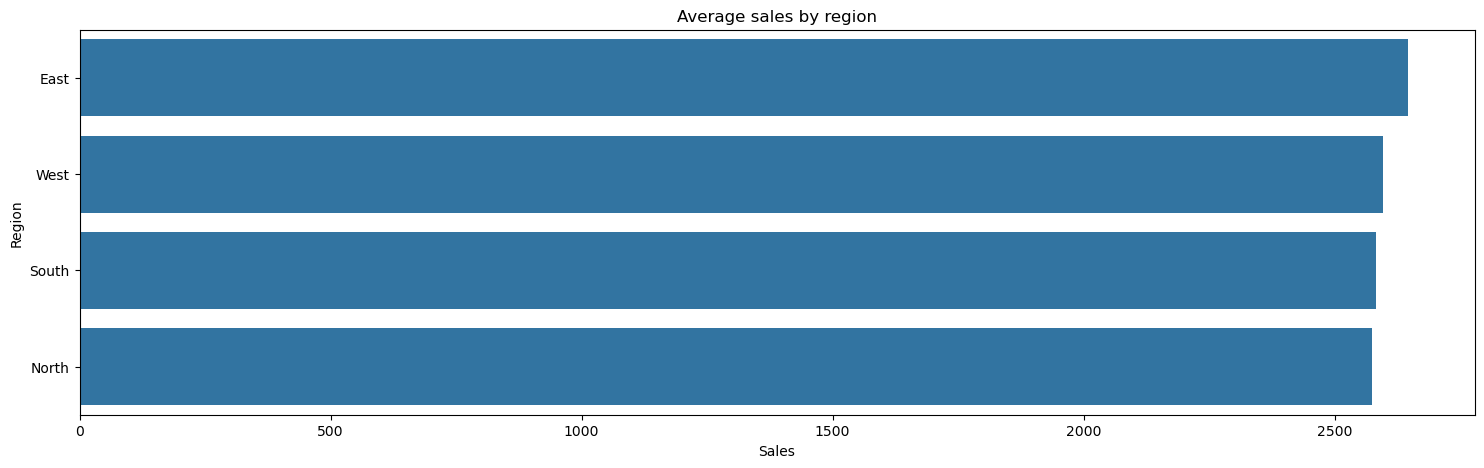

In [26]:
# Average sales by different region

plt.figure(figsize=(18,5))

sns.barplot(x="Sales", y="Region", data=df, orient="h", errorbar=None)
plt.title("Average sales by region")

plt.show()

**Insight**: The east region slightly outperforms others, indicating potential regional dominance

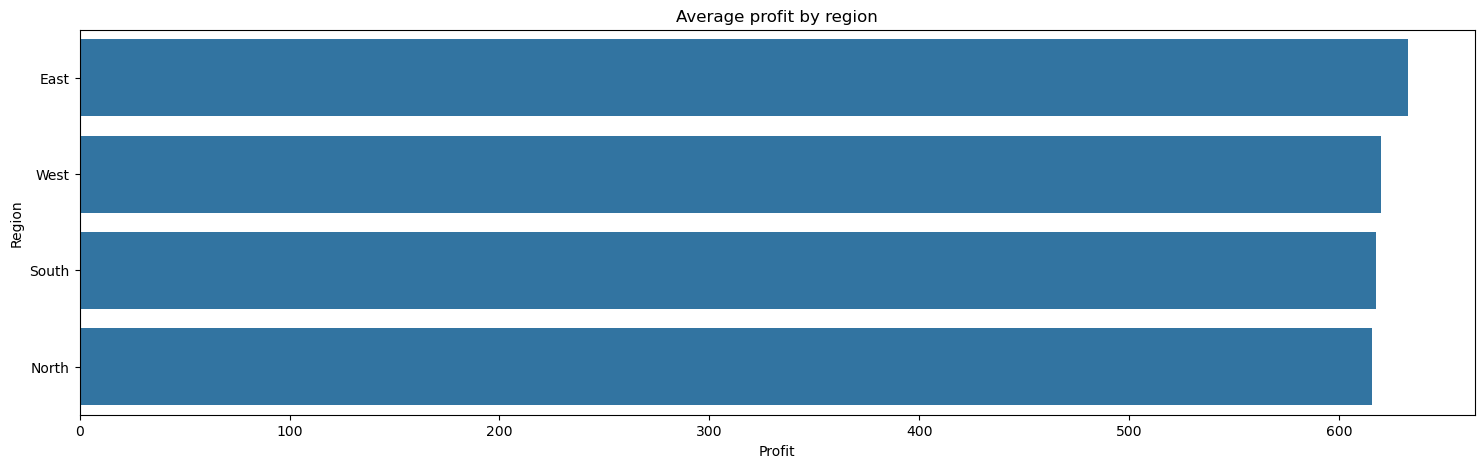

In [27]:
plt.figure(figsize=(18,5))

sns.barplot(x="Profit", y="Region", data=df, orient="h", errorbar=None)
plt.title("Average profit by region")

plt.show()

**Insight**: Again, the east region slightly outperforms others.

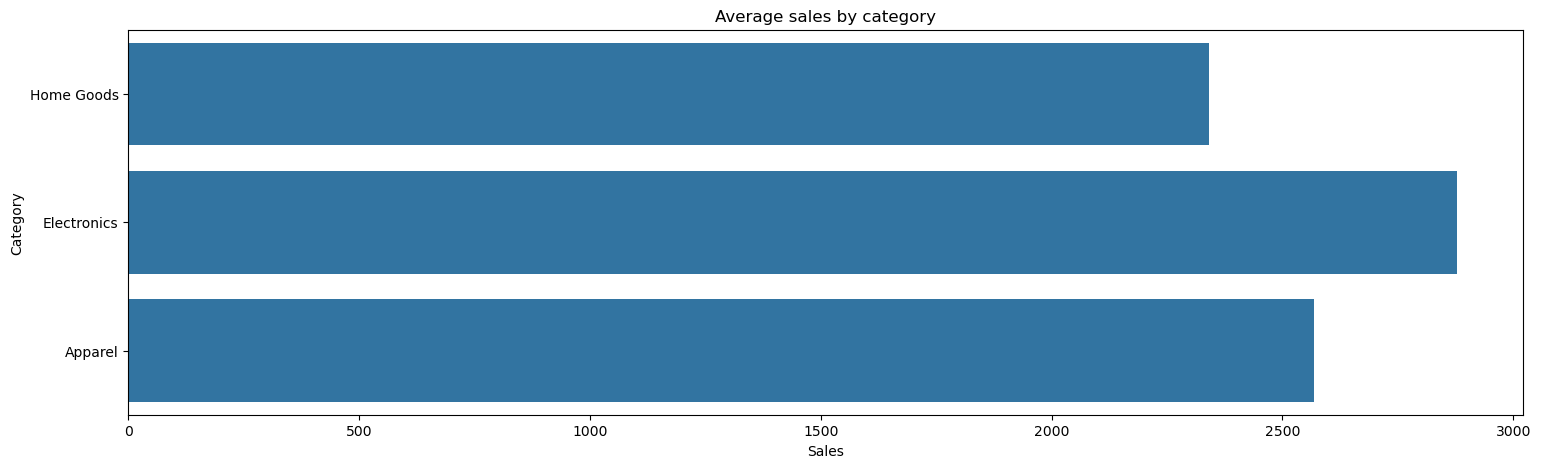

In [28]:
# Average sales by category

plt.figure(figsize=(18,5))

sns.barplot(x="Sales", y="Category", data=df, orient="h", errorbar=None)
plt.title("Average sales by category")

plt.show()

**Insight**: Electronics lead the sales, while home goods perform relatively lower.

# Correlation between sales and profit

In [29]:
df.head(2)

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit,Year_Month
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.90,2022-01
1,2022-01-02,Electronics,West,Cloudy,1893.89,24.74,January,2022,Winter,3859.05,147,924.16,2022-01


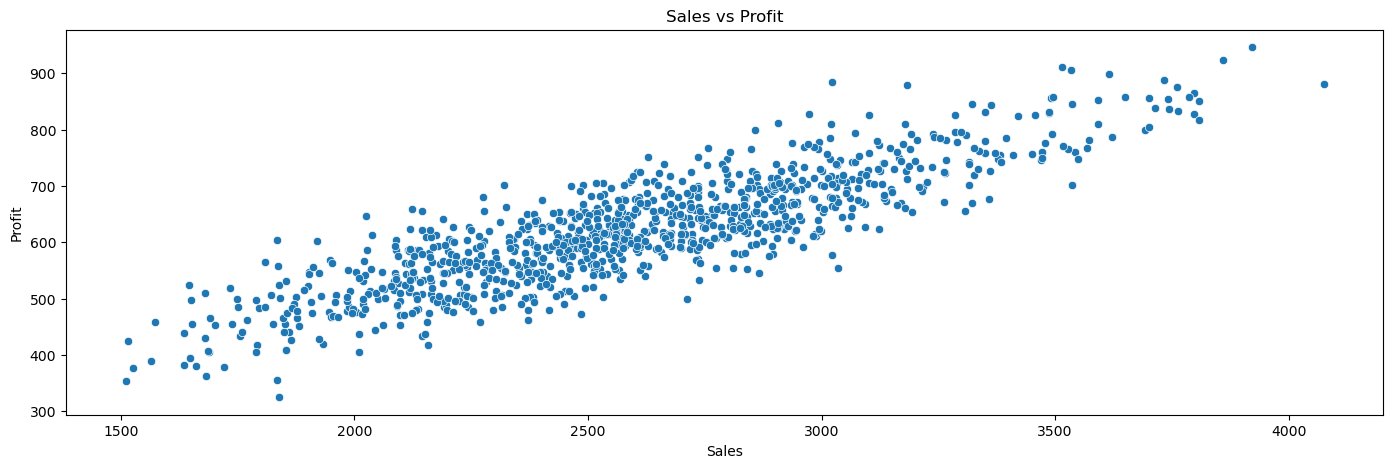

In [30]:
plt.figure(figsize=(17,5))

sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sales vs Profit")

plt.show()

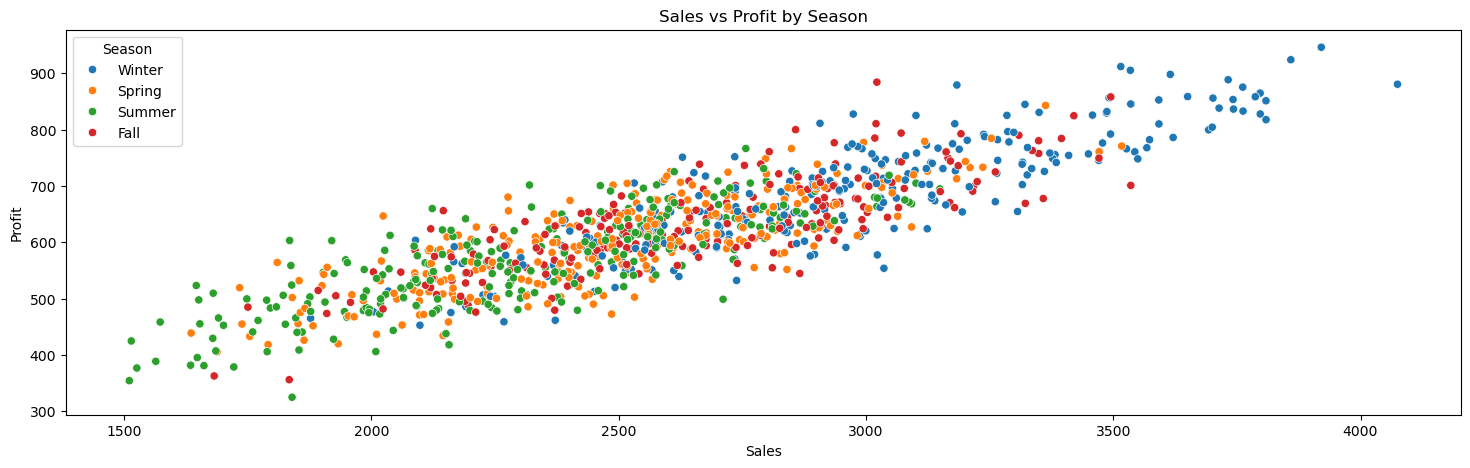

In [31]:
# Sales vs Profits by Season

plt.figure(figsize=(18,5))

sns.scatterplot(x="Sales", y="Profit", data=df, hue="Season")
plt.title("Sales vs Profit by Season")

plt.show()

**Insight**: Positive correlation exist between sales and profit, with clear seasonal variation. With winter being the most profitable season

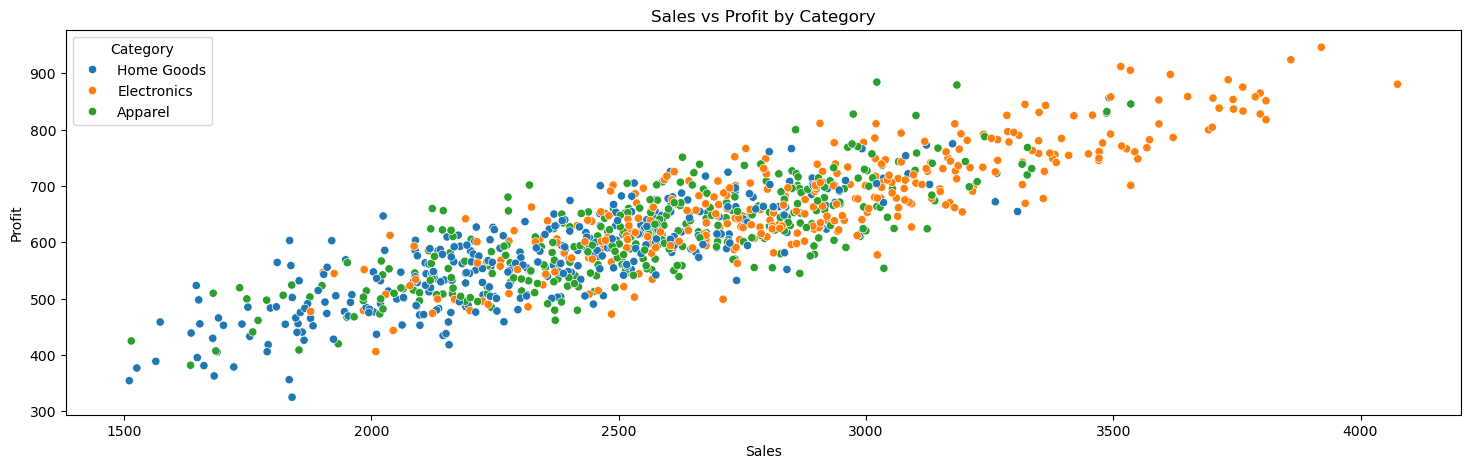

In [32]:
# Sales vs Profits by Category

plt.figure(figsize=(18,5))

sns.scatterplot(x="Sales", y="Profit", data=df, hue="Category")
plt.title("Sales vs Profit by Category")

plt.show()

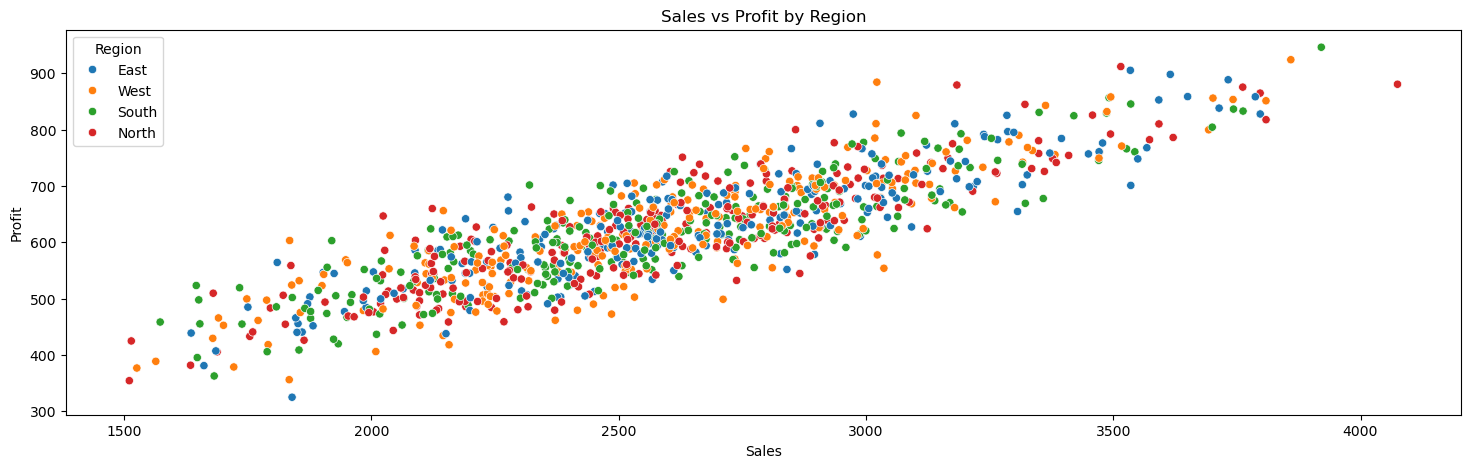

In [33]:
# Sales vs Profits by Region

plt.figure(figsize=(18,5))

sns.scatterplot(x="Sales", y="Profit", data=df, hue="Region")
plt.title("Sales vs Profit by Region")

plt.show()

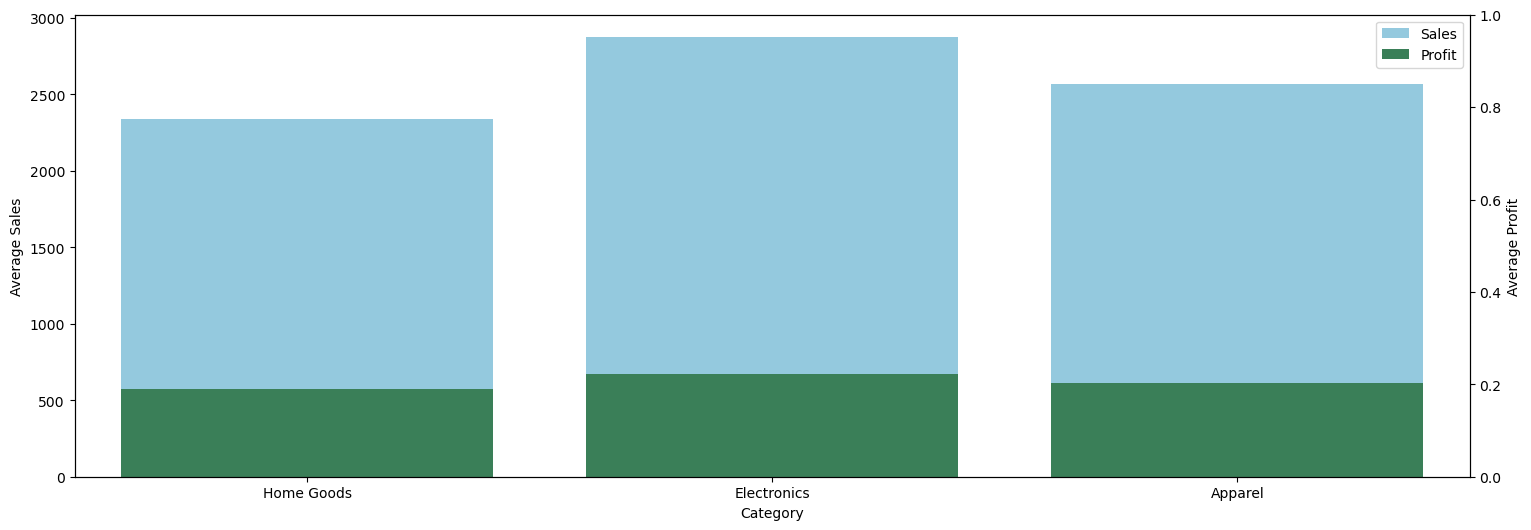

In [34]:
fig, ax = plt.subplots(figsize=(18,6))

sns.barplot(x="Category", y="Sales", data=df, color="Skyblue", label="Sales", errorbar=None, ax=ax)
plt.ylabel("Average Sales")
ax.twinx()
sns.barplot(x="Category", y="Profit", data=df, color="Seagreen", label="Profit", errorbar=None, ax=ax)
plt.ylabel("Average Profit")

plt.show()

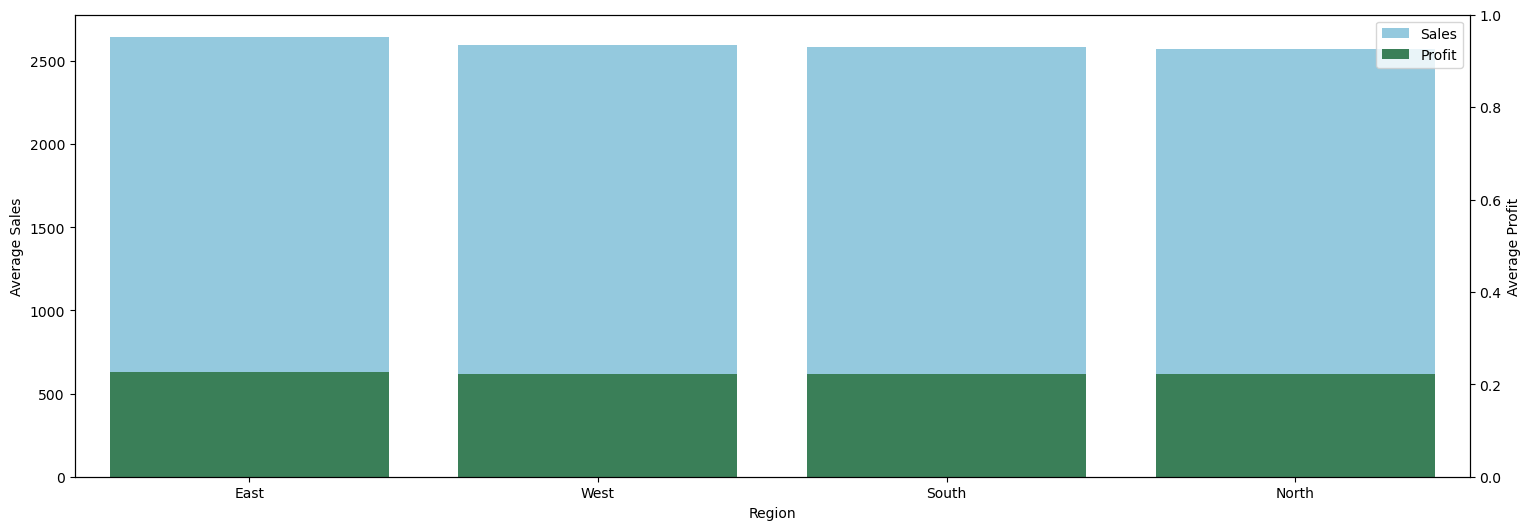

In [35]:
fig, ax = plt.subplots(figsize=(18,6))

sns.barplot(x="Region", y="Sales", data=df, color="Skyblue", label="Sales", errorbar=None, ax=ax)
plt.ylabel("Average Sales")
ax.twinx()
sns.barplot(x="Region", y="Profit", data=df, color="Seagreen", label="Profit", errorbar=None, ax=ax)
plt.ylabel("Average Profit")

plt.show()

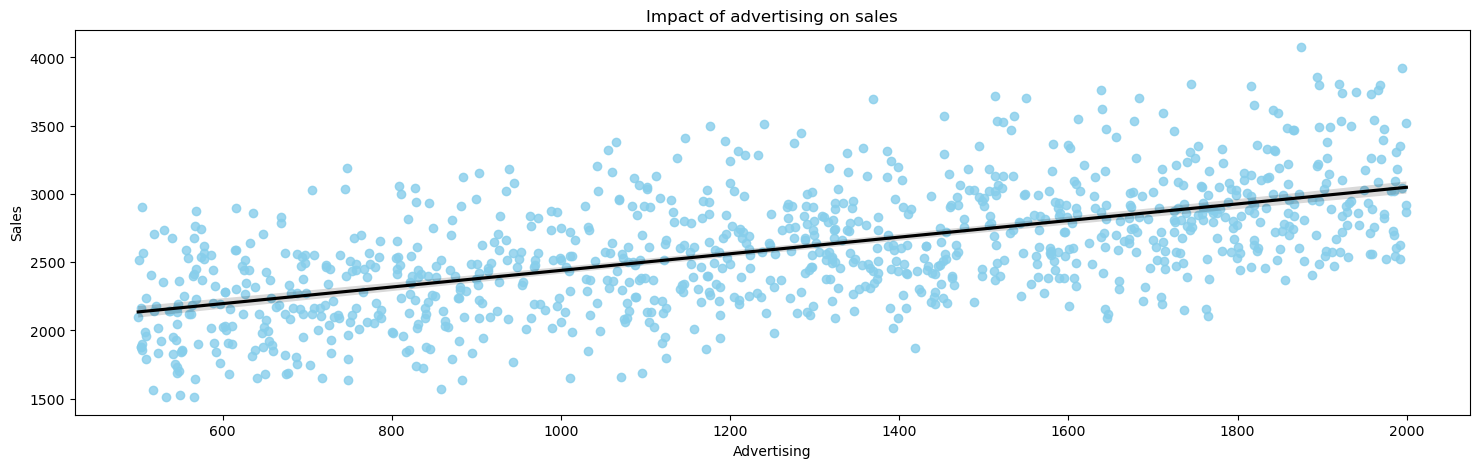

In [36]:
# Advertising impact on sales

plt.figure(figsize=(18,5))

sns.regplot(x="Advertising", y="Sales", data=df, color="skyblue", line_kws={"color":"black"})
plt.title("Impact of advertising on sales")

plt.show()

**Insight**: Higher advertising spend generally leads to higher sales.

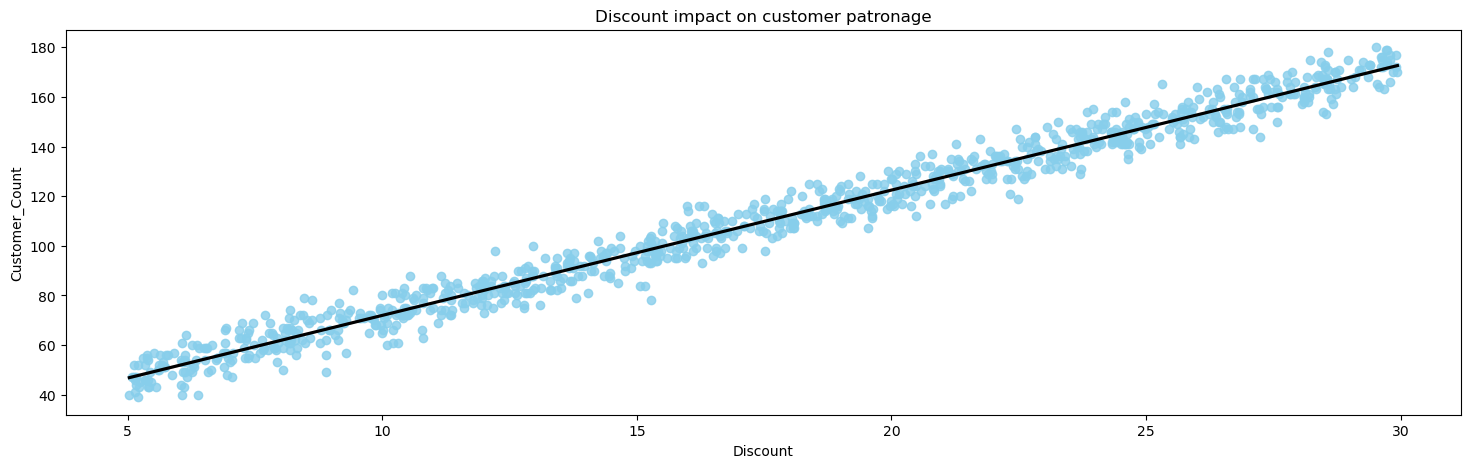

In [37]:
# Discount impact on customer patronage

plt.figure(figsize=(18,5))

sns.regplot(x="Discount", y="Customer_Count", data=df, color="skyblue", line_kws={"color":"black"})
plt.title("Discount impact on customer patronage")

plt.show()

**Insight**: Higher discounts leads to higher patronization from both new and old customers.

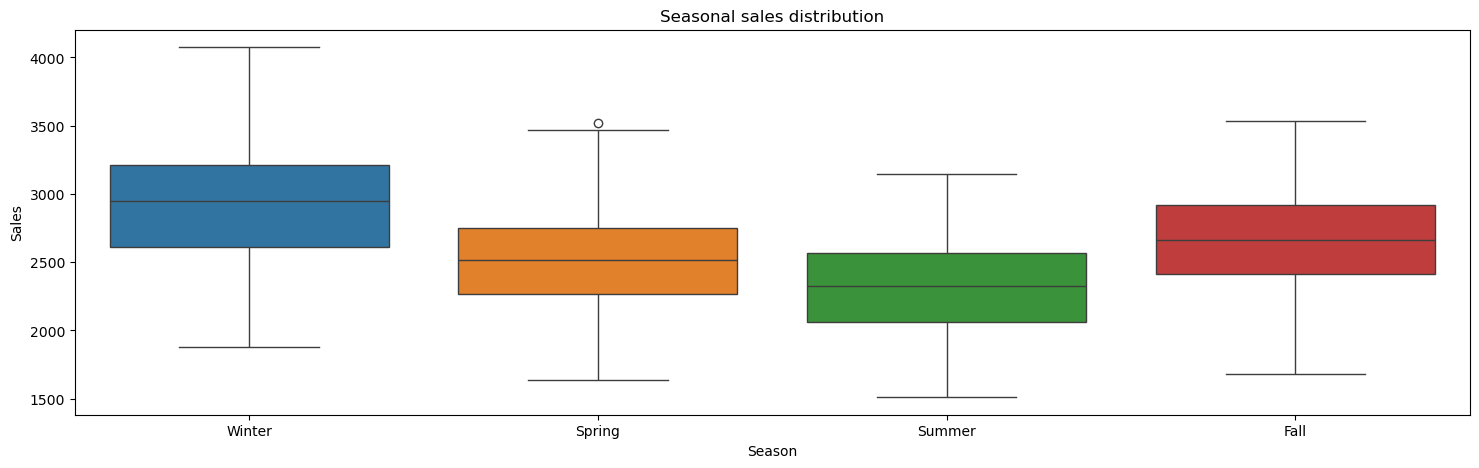

In [38]:
# Seasonal sales distribution

plt.figure(figsize=(18,5))

sns.boxplot(x="Season", y="Sales", hue="Season", data=df)
plt.title("Seasonal sales distribution")

plt.show()

**Insight**: Winter sees the highest sales, while summer has the lowest

# Correlation analysis

In [39]:
numeric_data = df.select_dtypes(include="number")
numeric_data

,Advertising,Discount,Year,Sales,Customer_Count,Profit
0,1275.18,15.74,2022,2679.56,95,652.90
1,1893.89,24.74,2022,3859.05,147,924.16
2,727.38,8.46,2022,2450.71,79,512.75
3,1757.23,15.37,2022,3056.75,97,624.60
4,1507.46,16.22,2022,2840.15,116,617.43
...,...,...,...,...,...,...
995,786.68,22.82,2024,2656.38,144,657.10
996,1798.73,17.82,2024,2994.30,114,624.29
997,936.72,29.62,2024,2516.03,176,560.81
998,1210.10,11.82,2024,2190.39,85,527.86


In [40]:
correlation_map=numeric_data.corr()
correlation_map

,Advertising,Discount,Year,Sales,Customer_Count,Profit
Advertising,1.000000,-0.041544,0.052870,0.596664,-0.032036,0.508804
Discount,-0.041544,1.000000,-0.021071,0.276811,0.989094,0.223716
Year,0.052870,-0.021071,1.000000,-0.021249,-0.037677,0.006903
Sales,0.596664,0.276811,-0.021249,1.000000,0.309698,0.861604
Customer_Count,-0.032036,0.989094,-0.037677,0.309698,1.000000,0.248441
Profit,0.508804,0.223716,0.006903,0.861604,0.248441,1.000000


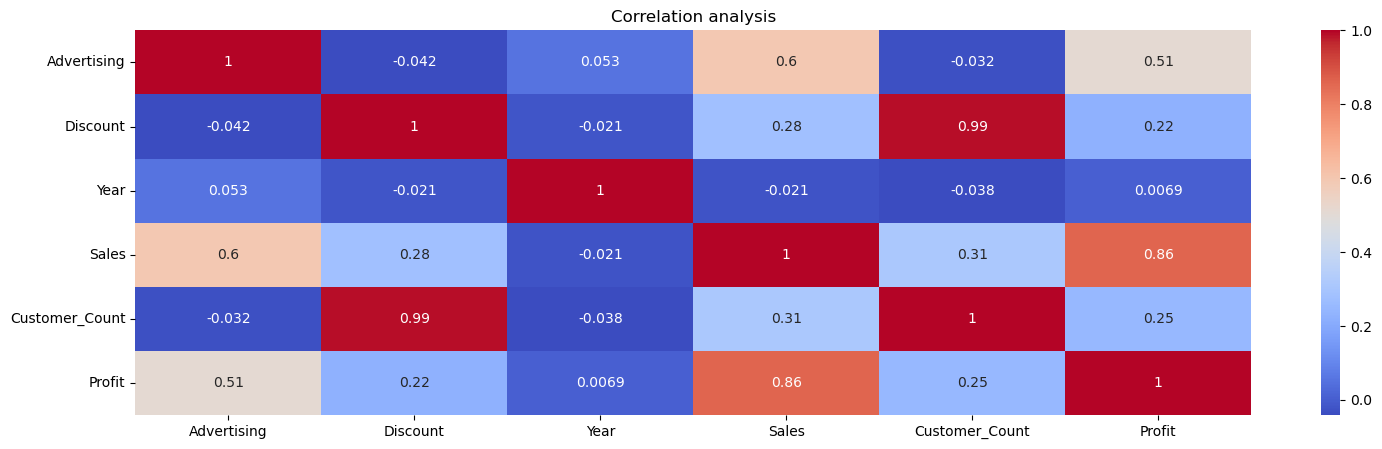

In [41]:
plt.figure(figsize=(18,5))

sns.heatmap(correlation_map, annot=True, cmap="coolwarm")
plt.title("Correlation analysis")

plt.show()

**Insight**: Sales and profit have a strong positive correlation, while discounts show weak relationships with profit and sales. Discount shows a very strong positive correlation with customer count indicating that discount attracts more customers.

## Conclusions — What Has Been Achieved

The EDA delivered a clear, evidence-based picture of RetailMart's performance across nearly three years of data (Jan 2022 – Sep 2024):

- **Strong seasonality confirmed.** Sales and customer activity peak in the **holiday months (September–December)** and across **Winter and Fall**, and dip in **Spring and Summer** — with **Winter the most profitable season**.
- **Advertising is a genuine sales driver.** Advertising spend correlates positively with **sales (r ≈ 0.60)** and **profit (r ≈ 0.51)**. The 2023 episode is telling: raising the budget during a customer-activity slump revived sales to an all-time high.
- **A timing mismatch was identified.** Historically, advertising spend was *reduced* during the very holiday periods when demand peaks — a missed opportunity to amplify already-strong sales.
- **Discounts drive footfall but not margin.** Discounts have a **very strong** link to customer count **(r ≈ 0.99)** but only a **weak** link to sales **(r ≈ 0.28)** and profit **(r ≈ 0.22)** — deep discounting attracts customers without proportionally growing revenue or profit.
- **Sales reliably convert to profit.** Sales and profit are **strongly correlated (r ≈ 0.86)**, so initiatives that grow sales dependably grow profit.
- **Category and regional leaders found.** **Electronics** lead on sales (Home Goods lowest), and the **East** region slightly outperforms the others on both sales and profit.

## Business Recommendations

- **Re-time advertising to match demand.** Shift more of the advertising budget into the high-demand **September–December / Winter** window instead of cutting it, to capitalise on peak buying intent; maintain a protected baseline spend year-round to avoid the kind of Spring slump seen in 2023.
- **Use discounts surgically, not broadly.** Because discounts boost footfall but erode margin, target them at **off-peak seasons (Spring/Summer)** to lift traffic when it is naturally low, and avoid deep discounts during peak months when customers already convert at full price.
- **Lead peak season with Electronics.** Prioritise **Electronics** — the top-selling category — in holiday campaigns and inventory planning, and test **cross-category bundles** (e.g., pairing Apparel or Home Goods with Electronics) to lift weaker categories.
- **Replicate the East region's edge.** Investigate what drives the East's higher sales and profit (assortment, pricing, store mix) and roll those practices out to **North, South, and West**.
- **Support underperforming areas with margin-aware promotions.** Pair targeted advertising with selective offers in weaker categories/regions (e.g., Home Goods) rather than blanket discounting.
- **Monitor with a seasonal dashboard.** Track sales, profit, advertising, and customer count by **month, season, category, and region** so budget and discount decisions can be tuned in near-real time.